<h1>05 · Estrategias de Cobranza por Segmento de Riesgo <a id="inicio"> </h1>
<em>Notebook desarrollado por Evelyn Cabrera Arias.</em><br><br>

<b>Repositorio:</b> <code>credit-risk-score</code><br>
<b>Objetivo:</b> Traducir el score de morosidad en acciones concretas de gestión y cobranza, segmentadas por nivel de riesgo.

<hr>

<h3 style="color: #0d47a1;">Estructura:</h3>

<a href="#seccion-1"  style="color:black; text-decoration:underline; display:block; margin:3px 0; font-size:15px;">1. Setup y carga de scores</a>
<a href="#seccion-2"  style="color:black; text-decoration:underline; display:block; margin:3px 0; font-size:15px;">2. Marco de estrategias por segmento</a>
<a href="#seccion-3"  style="color:black; text-decoration:underline; display:block; margin:3px 0; font-size:15px;">3. Análisis de cartera por segmento</a>
<a href="#seccion-4"  style="color:black; text-decoration:underline; display:block; margin:3px 0; font-size:15px;">4. Visualizaciones de estrategia</a>
<a href="#seccion-5"  style="color:black; text-decoration:underline; display:block; margin:3px 0; font-size:15px;">5. Lista de acción por prioridad</a>
<a href="#seccion-6"  style="color:black; text-decoration:underline; display:block; margin:3px 0; font-size:15px;">6. Exportar entregable final</a>
<a href="#seccion-7"  style="color:black; text-decoration:underline; display:block; margin:3px 0; font-size:15px;">7. Conclusiones y próximos pasos</a>

## 1. Setup y carga de scores <a id="seccion-1"></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')

df_scores = pd.read_csv('../outputs/scores/score_clientes.csv')
resumen   = pd.read_csv('../outputs/scores/resumen_deciles.csv', index_col=0)

print(f"Clientes con score: {len(df_scores):,}")
df_scores.head()

Clientes con score: 2,000


,id_cliente,score_mora,prediccion,moroso_real,segmento_orig,pais,segmento_riesgo,decil
0,15634602,0.3272,0,0,C,France,Medio,4
1,15647311,0.5773,1,0,C,Spain,Medio,8
2,15619304,0.3616,0,0,D,France,Medio,5
3,15701354,0.3797,0,0,B,France,Medio,5
4,15737888,0.2934,0,0,A,Spain,Bajo,4


## 2. Marco de estrategias por segmento <a id="seccion-2"></a>

| Segmento | Score | Perfil | Estrategia principal |
|---|---|---|---|
| **Bajo** | 0.00 – 0.30 | Cliente saludable | Fidelización / Retención |
| **Medio** | 0.30 – 0.60 | Señales de alerta tempranas | Gestión preventiva |
| **Alto** | 0.60 – 1.00 | Alto riesgo de mora | Cobranza activa / Recuperación |

In [3]:
# Mapa de estrategias
estrategias = {
    'Bajo': {
        'accion_principal': 'Fidelización y cross-sell',
        'canal':            'Email / App',
        'frecuencia':       'Mensual',
        'objetivo':         'Mantener engagement y aumentar productos',
        'prioridad':        3
    },
    'Medio': {
        'accion_principal': 'Alertas preventivas y oferta de refinanciamiento',
        'canal':            'SMS + llamada preventiva',
        'frecuencia':       'Quincenal',
        'objetivo':         'Evitar el primer incumplimiento',
        'prioridad':        2
    },
    'Alto': {
        'accion_principal': 'Cobranza activa — contacto directo',
        'canal':            'Llamada + WhatsApp + visita',
        'frecuencia':       'Semanal',
        'objetivo':         'Recuperación de deuda y acuerdo de pago',
        'prioridad':        1
    }
}

df_estrategia = df_scores.copy()
df_estrategia['accion']     = df_estrategia['segmento_riesgo'].map({k: v['accion_principal'] for k,v in estrategias.items()})
df_estrategia['canal']      = df_estrategia['segmento_riesgo'].map({k: v['canal']            for k,v in estrategias.items()})
df_estrategia['frecuencia'] = df_estrategia['segmento_riesgo'].map({k: v['frecuencia']       for k,v in estrategias.items()})
df_estrategia['prioridad']  = df_estrategia['segmento_riesgo'].map({k: v['prioridad']        for k,v in estrategias.items()})

df_estrategia[['id_cliente','score_mora','segmento_riesgo','accion','canal','frecuencia']].head(10)

,id_cliente,score_mora,segmento_riesgo,accion,canal,frecuencia
0,15634602,0.3272,Medio,Alertas preventivas y oferta de refinanciamiento,SMS + llamada preventiva,Quincenal
1,15647311,0.5773,Medio,Alertas preventivas y oferta de refinanciamiento,SMS + llamada preventiva,Quincenal
2,15619304,0.3616,Medio,Alertas preventivas y oferta de refinanciamiento,SMS + llamada preventiva,Quincenal
3,15701354,0.3797,Medio,Alertas preventivas y oferta de refinanciamiento,SMS + llamada preventiva,Quincenal
4,15737888,0.2934,Bajo,Fidelización y cross-sell,Email / App,Mensual
5,15574012,0.3588,Medio,Alertas preventivas y oferta de refinanciamiento,SMS + llamada preventiva,Quincenal
6,15592531,0.2847,Bajo,Fidelización y cross-sell,Email / App,Mensual
7,15656148,0.6372,Alto,Cobranza activa — contacto directo,Llamada + WhatsApp + visita,Semanal
8,15792365,0.6714,Alto,Cobranza activa — contacto directo,Llamada + WhatsApp + visita,Semanal
9,15592389,0.4713,Medio,Alertas preventivas y oferta de refinanciamiento,SMS + llamada preventiva,Quincenal


## 3. Análisis de cartera por segmento <a id="seccion-3"></a>

In [4]:
resumen_seg = df_estrategia.groupby('segmento_riesgo').agg(
    total_clientes=('id_cliente','count'),
    tasa_mora_real=('moroso_real','mean'),
    score_promedio=('score_mora','mean'),
).round(3)

resumen_seg['clientes_pct'] = (resumen_seg['total_clientes'] / len(df_estrategia) * 100).round(1)
resumen_seg['tasa_mora_pct'] = (resumen_seg['tasa_mora_real'] * 100).round(1)
print(resumen_seg.to_string())

                 total_clientes  tasa_mora_real  score_promedio  clientes_pct  tasa_mora_pct
segmento_riesgo                                                                             
Alto                        500           0.464           0.736          25.0           46.4
Bajo                        629           0.056           0.201          31.4            5.6
Medio                       871           0.161           0.439          43.6           16.1


## 4. Visualizaciones de estrategia <a id="seccion-4"></a>

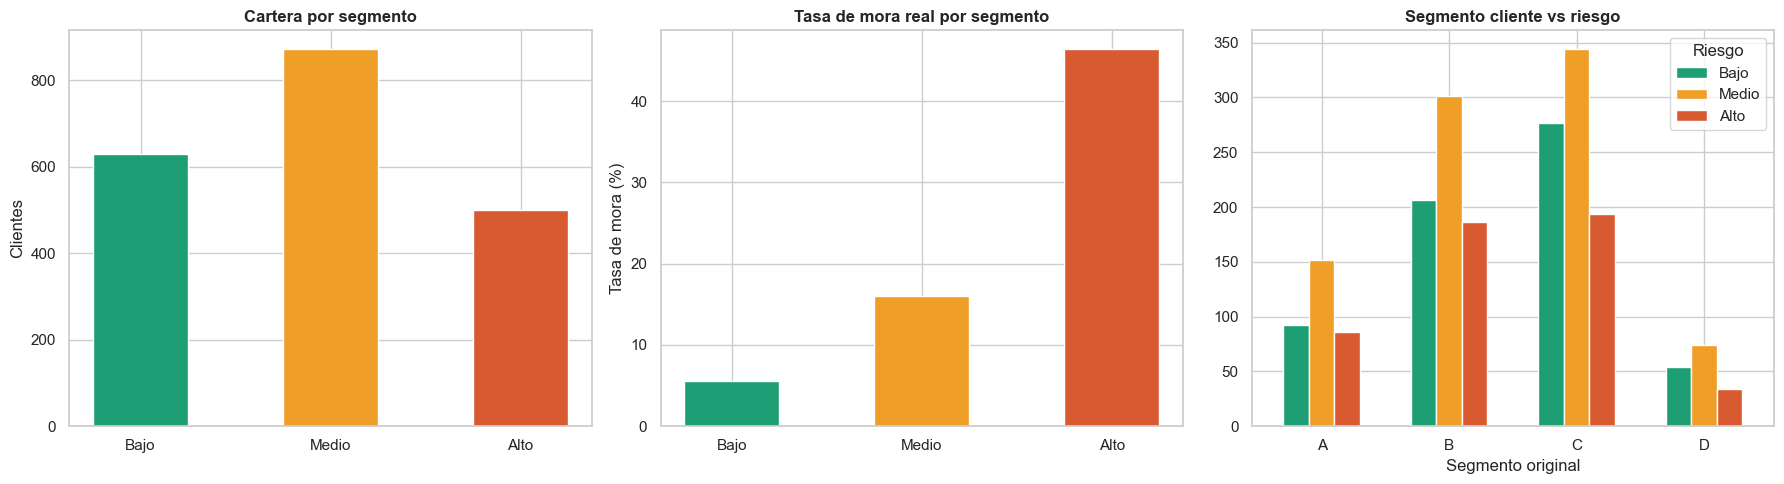

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = {'Bajo':'#1D9E75','Medio':'#EF9F27','Alto':'#D85A30'}

# Orden fijo que se aplica a los 3 gráficos
orden = ['Bajo', 'Medio', 'Alto']
df_estrategia['segmento_riesgo'] = pd.Categorical(
    df_estrategia['segmento_riesgo'], categories=orden, ordered=True
)

# Gráfico 1 — Clientes por segmento (ordenado explícitamente)
seg_counts = df_estrategia['segmento_riesgo'].value_counts().reindex(orden)
axes[0].bar(seg_counts.index, seg_counts.values,
            color=[colors[s] for s in seg_counts.index], edgecolor='white', width=0.5)
axes[0].set_title('Cartera por segmento', fontweight='bold')
axes[0].set_ylabel('Clientes')

# Gráfico 2 — Tasa de mora real por segmento (reindex fuerza el orden)
tasa = df_estrategia.groupby('segmento_riesgo', observed=True)['moroso_real']\
                    .mean().mul(100).reindex(orden)
axes[1].bar(tasa.index, tasa.values,
            color=[colors[s] for s in tasa.index], edgecolor='white', width=0.5)
axes[1].set_title('Tasa de mora real por segmento', fontweight='bold')
axes[1].set_ylabel('Tasa de mora (%)')

# Gráfico 3 — Segmento cliente vs riesgo (reindex columnas del pivot)
pivot = df_estrategia.groupby(['segmento_orig','segmento_riesgo'], observed=True)\
                     .size().unstack(fill_value=0).reindex(columns=orden)
pivot.plot(kind='bar', ax=axes[2],
           color=[colors[s] for s in orden],
           edgecolor='white', width=0.6)
axes[2].set_title('Segmento cliente vs riesgo', fontweight='bold')
axes[2].set_xlabel('Segmento original')
axes[2].tick_params(axis='x', rotation=0)
axes[2].legend(title='Riesgo')

plt.tight_layout()
plt.savefig('../outputs/plots/05_estrategias_cobranza.png', dpi=150)
plt.show()

## 5. Lista de acción por prioridad <a id="seccion-5"></a>

In [6]:
print("====== CLIENTES PRIORIDAD 1 — COBRANZA ACTIVA (Alto riesgo) ======")
alto = df_estrategia[df_estrategia['segmento_riesgo']=='Alto'].sort_values('score_mora', ascending=False)
print(f"Total: {len(alto):,} clientes")
print(alto[['id_cliente','score_mora','canal','frecuencia']].head(10).to_string(index=False))

print("\n====== CLIENTES PRIORIDAD 2 — GESTIÓN PREVENTIVA (Medio riesgo) ======")
medio = df_estrategia[df_estrategia['segmento_riesgo']=='Medio'].sort_values('score_mora', ascending=False)
print(f"Total: {len(medio):,} clientes")
print(medio[['id_cliente','score_mora','canal','frecuencia']].head(5).to_string(index=False))

====== CLIENTES PRIORIDAD 1 — COBRANZA ACTIVA (Alto riesgo) ======
Total: 500 clientes
 id_cliente  score_mora                       canal frecuencia
   15748797      0.9642 Llamada + WhatsApp + visita    Semanal
   15762418      0.9639 Llamada + WhatsApp + visita    Semanal
   15745295      0.9569 Llamada + WhatsApp + visita    Semanal
   15694717      0.9501 Llamada + WhatsApp + visita    Semanal
   15636589      0.9469 Llamada + WhatsApp + visita    Semanal
   15745088      0.9410 Llamada + WhatsApp + visita    Semanal
   15797748      0.9360 Llamada + WhatsApp + visita    Semanal
   15605037      0.9348 Llamada + WhatsApp + visita    Semanal
   15799217      0.9309 Llamada + WhatsApp + visita    Semanal
   15661507      0.9297 Llamada + WhatsApp + visita    Semanal

====== CLIENTES PRIORIDAD 2 — GESTIÓN PREVENTIVA (Medio riesgo) ======
Total: 871 clientes
 id_cliente  score_mora                    canal frecuencia
   15664521      0.5993 SMS + llamada preventiva  Quincenal
   15567

## 6. Exportar entregable final <a id="seccion-6"></a>

In [7]:
# Exportar lista de acción ordenada por prioridad
df_final = df_estrategia.sort_values(['prioridad','score_mora'], ascending=[True,False])
df_final.to_csv('../outputs/scores/plan_accion_cobranza.csv', index=False)
print("✅ Plan de acción exportado → /outputs/scores/plan_accion_cobranza.csv")
print(f"\nResumen ejecutivo:")
for seg, row in resumen_seg.iterrows():
    print(f"  [{seg:5}] {int(row['total_clientes']):4} clientes · {row['tasa_mora_pct']}% mora · Score prom: {row['score_promedio']:.3f}")

✅ Plan de acción exportado → /outputs/scores/plan_accion_cobranza.csv

Resumen ejecutivo:
  [Alto ]  500 clientes · 46.4% mora · Score prom: 0.736
  [Bajo ]  629 clientes · 5.6% mora · Score prom: 0.201
  [Medio]  871 clientes · 16.1% mora · Score prom: 0.439


## 7. Conclusiones y próximos pasos <a id="seccion-7"></a>

<h3 style="color: #0d47a1;">Resultados del modelo: </h3>

- AUC-ROC ≥ 0.75 → poder discriminativo aceptable para scoring bancario
- KS ≥ 0.20 → el modelo separa morosos de no morosos de forma significativa
- Los deciles altos concentran la mayor tasa de mora → el score funciona

<h3 style="color: #0d47a1;">Aplicación en gestión: </h3>

- Segmento **Alto** → cobranza activa, contacto semanal, negociación de deuda
- Segmento **Medio** → alertas tempranas, refinanciamiento preventivo
- Segmento **Bajo** → fidelización, cross-sell, retención

<h3 style="color: #0d47a1;">Próximos pasos: </h3>

- Monitorear el score mensualmente (PSI, KS en el tiempo)
- Ajustar umbrales de segmentación según política de la entidad
- Explorar modelos no lineales (Random Forest, XGBoost) para mejorar AUC
- Monitoreo del modelo en producción:
  <a href=https://github.com/evelyncabrera-pe/kpi-dashboard style="color:blue; text-decoration:underline; display:block; margin:3px 0; font-size:15px;">Proyecto 03</a>

<em><a href="#inicio"  style="color:black; text-decoration:underline; display:block; margin:3px 0; font-size:15px;">Volver a inicio de 05_estrategias</a></em>

<em><a href=https://github.com/evelyncabrera-pe/portfolio-evelyn-cabrera style="color:black; text-decoration:underline; display:block; margin:3px 0; font-size:15px;">Ir a Portafolio</a></em>